In [10]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [11]:
# import os
# print(os.path.exists('./Dataset/fisayo_fosudo/fisayo.jpg'))

In [12]:
img=cv2.imread('./Dataset/fisayo_fosudo/fisayo_fosudo_364.jpg')
img.shape

(1000, 800, 3)

<h1 style='color:BLUe'>Data Cleaning</h1>

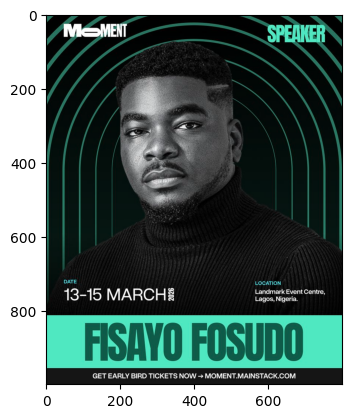

In [13]:
plt.imshow(img)

In [14]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(1000, 800)

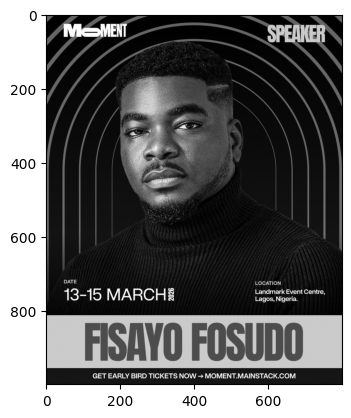

In [15]:
plt.imshow(gray, cmap='gray')

In [16]:
face_cascade = cv2.CascadeClassifier('./openCV/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./openCV/haarcascades/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

faces

array([[152, 175, 325, 325]], dtype=int32)

In [17]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(152), np.int32(175), np.int32(325), np.int32(325))

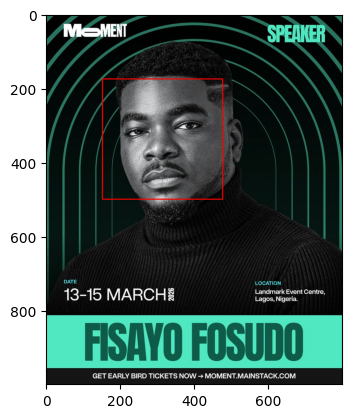

In [18]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

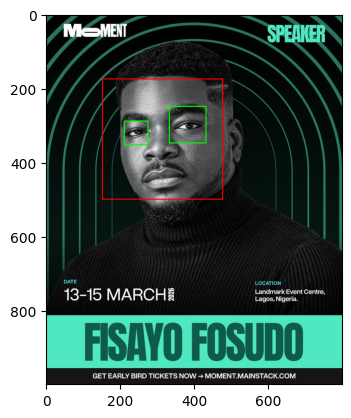

In [19]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

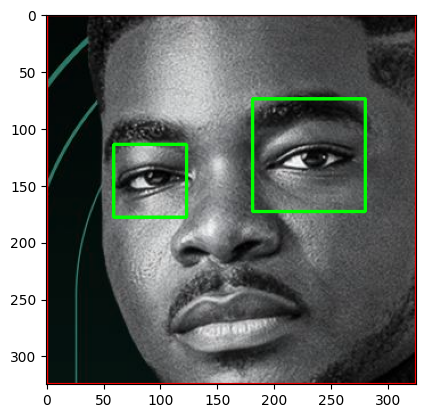

In [20]:
plt.imshow(roi_color, cmap='gray')

In [21]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

In [22]:
# original_image = cv2.imread('./Dataset/fisayo_fosudo/fisayo_fosudo_264.jpg')
# plt.imshow(original_image)

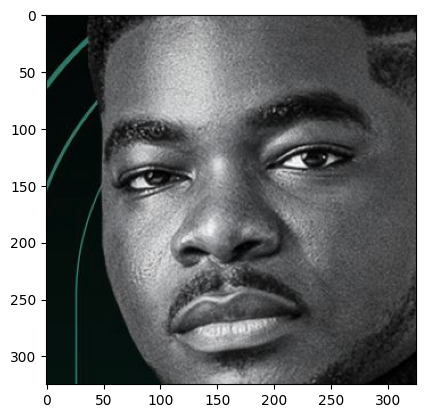

In [23]:
cropped_image = get_cropped_image_if_2_eyes('./Dataset/fisayo_fosudo/fisayo_fosudo_364.jpg')
plt.imshow(cropped_image)

In [24]:
path_to_data = "./Dataset/"
path_to_cr_data = "./Dataset/cropped/"

In [25]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [26]:
img_dirs

['./Dataset/cropped',
 './Dataset/elon musk',
 './Dataset/fisayo_fosudo',
 './Dataset/jensen huang',
 './Dataset/mark zuckerberg',
 './Dataset/silas adekunle']

In [27]:
# import os

# def rename_pictures(folder_path, new_name_prefix="image", start_number=1):
#     """
#     Rename all picture files in a folder with a consistent naming pattern.
    
#     Parameters:
#         folder_path: Path to the folder containing images
#         new_name_prefix: Base name for renamed files (e.g., "image" -> image_001.jpg)
#         start_number: Starting number for the sequence
#     """
    
#     # Common image extensions
#     image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')
    
#     # Get all image files
#     files = [f for f in os.listdir(folder_path) 
#              if f.lower().endswith(image_extensions)]
#     files.sort()  # Sort to maintain order
    
#     renamed_count = 0
    
#     for i, filename in enumerate(files, start=start_number):
#         # Get original file extension (preserve case or lowercase it)
#         old_path = os.path.join(folder_path, filename)
#         ext = os.path.splitext(filename)[1].lower()
        
#         # Create new filename: e.g., image_001.jpg
#         new_filename = f"{new_name_prefix}_{i:03d}{ext}"
#         new_path = os.path.join(folder_path, new_filename)
        
#         # Handle name collisions
#         while os.path.exists(new_path):
#             i += 1
#             new_filename = f"{new_name_prefix}_{i:03d}{ext}"
#             new_path = os.path.join(folder_path, new_filename)
        
#         os.rename(old_path, new_path)
#         print(f"Renamed: {filename} -> {new_filename}")
#         renamed_count += 1
    
#     print(f"\nDone! Renamed {renamed_count} files.")

# # Example usage:
# # rename_pictures("./MODEL/Dataset/fisayo_fosudo", new_name_prefix="fisayo", start_number=1)

In [28]:
# # Rename all images in your celebrity folders
# import os

# base_dir = "./Dataset"

# for celebrity_folder in os.listdir(base_dir):
#     folder_path = os.path.join(base_dir, celebrity_folder)
#     if os.path.isdir(folder_path):
#         rename_pictures(folder_path, new_name_prefix=celebrity_folder.lower(), start_number=1)

In [29]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [31]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = img_dir.split('/')[-1]
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + celebrity_name
            
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ",cropped_folder)
                
                      
                
                
            cropped_file_name = celebrity_name + str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
            cv2.imwrite(cropped_file_path, roi_color)
            celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
            count += 1    

cropped
elon musk
Generating cropped images in folder:  ./Dataset/cropped/elon musk
fisayo_fosudo
Generating cropped images in folder:  ./Dataset/cropped/fisayo_fosudo
jensen huang
Generating cropped images in folder:  ./Dataset/cropped/jensen huang
mark zuckerberg
Generating cropped images in folder:  ./Dataset/cropped/mark zuckerberg
silas adekunle
Generating cropped images in folder:  ./Dataset/cropped/silas adekunle


In [32]:
cropped_file_name = celebrity_name + str(count) + ".png"
cropped_file_path = cropped_folder + "/" + cropped_file_name 
            
cv2.imwrite(cropped_file_path, roi_color)
celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
count += 1  

<h1 style='color:yellow'>Data Preprocessing</h1>

In [33]:
# import numpy as np
import pywt
# import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

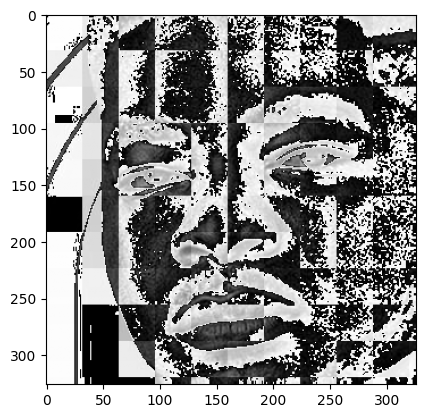

In [34]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har, cmap='gray')

In [42]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'elon musk': 0,
 'fisayo_fosudo': 1,
 'jensen huang': 2,
 'mark zuckerberg': 3,
 'silas adekunle': 4}

In [39]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{'elon musk': ['./Dataset/cropped/elon musk\\elon musk1.png',
  './Dataset/cropped/elon musk\\elon musk10.png',
  './Dataset/cropped/elon musk\\elon musk100.png',
  './Dataset/cropped/elon musk\\elon musk101.png',
  './Dataset/cropped/elon musk\\elon musk102.png',
  './Dataset/cropped/elon musk\\elon musk103.png',
  './Dataset/cropped/elon musk\\elon musk104.png',
  './Dataset/cropped/elon musk\\elon musk105.png',
  './Dataset/cropped/elon musk\\elon musk106.png',
  './Dataset/cropped/elon musk\\elon musk107.png',
  './Dataset/cropped/elon musk\\elon musk108.png',
  './Dataset/cropped/elon musk\\elon musk109.png',
  './Dataset/cropped/elon musk\\elon musk11.png',
  './Dataset/cropped/elon musk\\elon musk110.png',
  './Dataset/cropped/elon musk\\elon musk111.png',
  './Dataset/cropped/elon musk\\elon musk112.png',
  './Dataset/cropped/elon musk\\elon musk113.png',
  './Dataset/cropped/elon musk\\elon musk114.png',
  './Dataset/cropped/elon musk\\elon musk115.png',
  './Dataset/cropped/e

In [ ]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])    

In [ ]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(599, 4096)

bjugjjn<h1 style='color:ORANGE'>MODEL TRAINING</h1>

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.9666666666666667

In [ ]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           1       0.97      0.91      0.94        34
           2       0.95      1.00      0.97        19
           3       1.00      0.97      0.99        36
           4       0.95      0.97      0.96        37
           5       0.96      1.00      0.98        24

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [ ]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [ ]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [ ]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.935356,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.828489,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.939850,{'logisticregression__C': 1}


In [ ]:
from sklearn.metrics import confusion_matrix

# Step 1: Get predictions from your trained model
y_pred = clf.predict(X_test)   # replace 'clf' with your actual model variable

# Step 2: Confusion matrix with predictions, not features
cm = confusion_matrix(y_test, y_pred)
cm

array([[30,  1,  0,  2,  1],
       [ 0, 18,  0,  0,  1],
       [ 0,  0, 35,  1,  0],
       [ 0,  0,  0, 36,  1],
       [ 0,  0,  0,  0, 24]])

In [ ]:
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(y_test, X_test)
# cm

Text(95.72222222222221, 0.5, 'Truth')

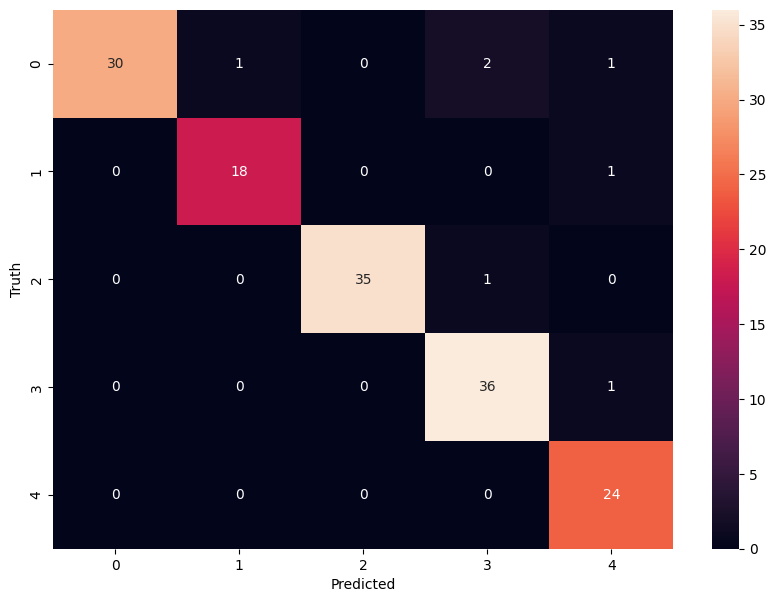

In [ ]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
class_dict

{'cropped': 0,
 'elon musk': 1,
 'fisayo_fosudo': 2,
 'jensen huang': 3,
 'mark zuckerberg': 4,
 'silas adekunle': 5}

In [45]:
# # # !pip install joblib
# import joblib 
# # Save the model as a pickle in a file 
# joblib.dump(best_clf, 'saved_model.pkl') 

In [44]:
# # # If you used GridSearchCV and stored it in 'clf':
# # joblib.dump(clf, 'saved_model.pkl')

# # # If you used a different variable name like 'model':
# # joblib.dump(model, 'saved_model.pkl')

# # # If you want the BEST estimator from GridSearchCV:
# joblib.dump(clf.best_estimator_, 'saved_model.pkl')

In [43]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict)) 